In [1]:
import os
import xarray as xr
import rioxarray
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
# Define file paths
era5_dir = "/global/scratch/users/yougsanghvi/era5_hourly_by_year/"  # Each GRIB per year
gdnat_dir = "/global/scratch/users/yougsanghvi/gdnat_tiff_files_by_yr/"     # Each TIFF per year

years = list(range(2000, 2005))  # 2000 to 2004

# Bounding box for mainland USA (approx)
usa_bounds = {
    "min_lon": -125,
    "max_lon": -66,
    "min_lat": 24,
    "max_lat": 50
}


In [8]:
era5_daily = []

for year in years:
    ds = xr.open_dataset(os.path.join(era5_dir, f"era5_data_{year}.grib"), engine="cfgrib")

    # Clip to mainland USA
    ds = ds.sel(latitude=slice(usa_bounds["max_lat"], usa_bounds["min_lat"]),
                longitude=slice(usa_bounds["min_lon"], usa_bounds["max_lon"]))

    # Resample to daily average
    ds_daily = ds.resample(time="1D").mean()

    # Add time-based columns
    ds_daily["year"] = ds_daily["time.year"]
    ds_daily["month"] = ds_daily["time.month"]
    ds_daily["day"] = ds_daily["time.day"]

    era5_daily.append(ds_daily)

era5_combined = xr.concat(era5_daily, dim="time")


/global/home/users/yougsanghvi/global_suicide_dummy/climate-env/lib64/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/global/home/users/yougsanghvi/global_suicide_dummy/climate-env/lib64/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/global/home/users/yougsanghvi/global_suicide_dummy/climate-env/lib64/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. 

In [5]:
gdnat_list = []

def convert_lon(lon):
    return lon + 360 if lon < 0 else lon

for year in years:
    gdnat_path = os.path.join(gdnat_dir, f"gdnat_{year}.tif")
    gdnat_ds = rioxarray.open_rasterio(gdnat_path)

    usa_bounds_360 = {
        "minx": convert_lon(usa_bounds["min_lon"]),  # -125 + 360 = 235
        "maxx": convert_lon(usa_bounds["max_lon"]),  # -66 + 360 = 294
        "miny": usa_bounds["min_lat"],               # 24
        "maxy": usa_bounds["max_lat"]                # 50
    }

    gdnat_ds = gdnat_ds.squeeze()  # remove band dimension
    gdnat_ds = gdnat_ds.expand_dims(time=[pd.Timestamp(f"{year}-01-01")])  # dummy time

    gdnat_list.append(gdnat_ds)

gdnat_combined = xr.concat(gdnat_list, dim="time")


In [13]:
temp_gdnat

<xarray.DataArray (time: 5, band: 365, y: 720, x: 1440)> Size: 8GB
array([[[[243.64174, 243.64174, 243.64174, ..., 243.64174, 243.64174,
          243.64174],
         [244.04518, 244.04585, 244.0464 , ..., 244.00575, 244.00624,
          244.00673],
         [244.17886, 244.2178 , 244.2189 , ..., 244.1769 , 244.17795,
          244.17862],
         ...,
         [259.85205, 260.0597 , 260.0667 , ..., 259.83783, 259.84265,
          259.847  ],
         [259.8628 , 260.06775, 260.0725 , ..., 259.8529 , 259.85638,
          259.85944],
         [258.4838 , 258.48605, 258.4882 , ..., 258.58032, 258.5821 ,
          258.58386]],

        [[243.29076, 243.29076, 243.29076, ..., 243.29076, 243.29076,
          243.29076],
         [243.12817, 243.12805, 243.1278 , ..., 243.11496, 243.11447,
          243.1141 ],
         [242.99744, 243.01053, 243.0101 , ..., 243.00317, 243.0022 ,
          243.00043],
...
         [251.45662, 251.40486, 251.4016 , ..., 251.46516, 251.46217,
          251.45938],
         [251.49507, 251.48009, 251.47865, ..., 251.50111, 251.49904,
          251.49702],
         [251.5479 , 251.54713, 251.54645, ..., 251.56386, 251.56264,
          251.56142]],

        [[249.40945, 249.40945, 249.40945, ..., 249.40945, 249.40945,
          249.40945],
         [249.39844, 249.39812, 249.39806, ..., 249.37001, 249.36993,
          249.36981],
         [249.3025 , 249.3302 , 249.32976, ..., 249.30428, 249.30397,
          249.30328],
         ...,
         [249.42216, 249.3867 , 249.385  , ..., 249.42676, 249.42517,
          249.42377],
         [249.22154, 249.22005, 249.21954, ..., 249.22404, 249.2233 ,
          249.22269],
         [248.90335, 248.90341, 248.90295, ..., 248.92873, 248.92836,
          248.92792]]]], shape=(5, 365, 720, 1440), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 40B 2000-01-01 2001-01-01 ... 2004-01-01
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * x            (x) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * y            (y) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
    spatial_ref  int64 8B 0
Attributes:
    bias_adjustment:  QuantileDeltaMapping(group=Grouper(name='time.dayofyear...
    Description:      Surface air temperature at the reference height (typica...
    history:          [2023-06-06 16:18:24] : Bias-adjusted with QuantileDelt...
    units:            K
    Variable names:   originally t2m in ERA5, tas in CMIP6 earth system model...
    AREA_OR_POINT:    Area
    _FillValue:       nan
    scale_factor:     1.0
    add_offset:       0.0
    long_name:        tas

TypeError: No numeric data to plot.

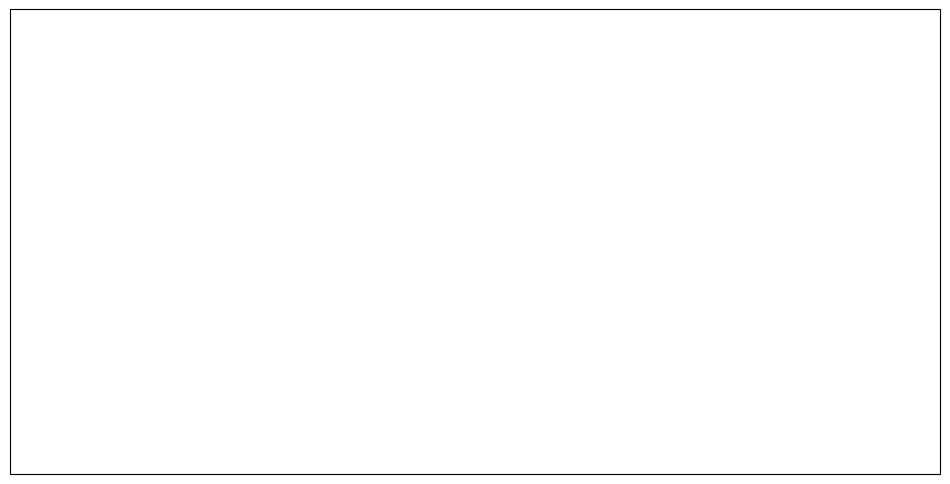

In [10]:
# Assuming ERA5 temperature variable is 't2m'
temp_era5 = era5_combined['t2m']  # replace with your var name
temp_gdnat = gdnat_combined  # if just 2D DataArray with time dim

temp_diff = temp_era5 - temp_gdnat

cc_mean = temp_diff.mean(dim='time')

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
cc_mean.plot(ax=ax, cmap='coolwarm', cbar_kwargs={'label': 'ERA5 - GDNat Temp (°C)'})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.set_title("Mean Temperature Difference (ERA5 - GDNat, 2000–2004)")
plt.show()


TypeError: No numeric data to plot.

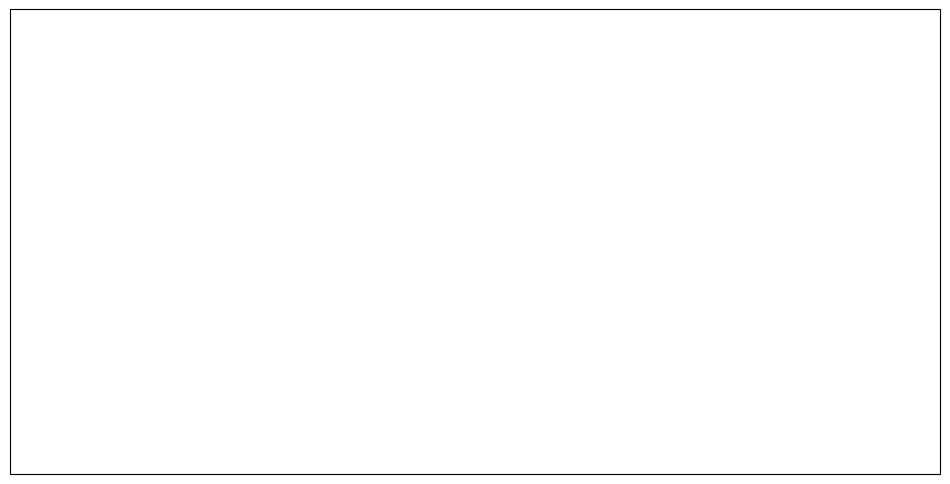

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
cc_mean.plot(ax=ax, cmap='coolwarm', cbar_kwargs={'label': 'ERA5 - GDNat Temp (°C)'})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.set_title("Mean Temperature Difference (ERA5 - GDNat, 2000–2004)")
plt.show()
